In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df = pd.read_csv("data/train.csv")

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


In [36]:
missing = df.isna().sum().to_frame("missing_count")
missing["missing_percent"] = missing["missing_count"] / len(df) * 100
missing

,missing_count,missing_percent
id,0,0.0
vendor_id,0,0.0
pickup_datetime,0,0.0
dropoff_datetime,0,0.0
passenger_count,0,0.0
pickup_longitude,0,0.0
pickup_latitude,0,0.0
dropoff_longitude,0,0.0
dropoff_latitude,0,0.0
store_and_fwd_flag,0,0.0


There are no missing values in the dataset, so imputation is not required. Therefore, the main data-quality concerns are not missingness but invalid values, outliers, unrealistic coordinates, and impossible trip speeds.

In [37]:
df.drop(columns=["id","dropoff_datetime"],inplace=True) #dropping id column since it is irrelvant for the analysis and prediction

We also remove the dropoff datetime as it is post-trip information and cause data leakage because it is only known after a trip and directly tells us the duration (along with pickup time)

In [38]:
df.head()

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,2,2016-03-14 17:24:55,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,1,2016-06-12 00:43:35,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,2,2016-01-19 11:35:24,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,2,2016-04-06 19:32:31,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,2,2016-03-26 13:30:55,1,-73.973053,40.793209,-73.972923,40.782520,N,435


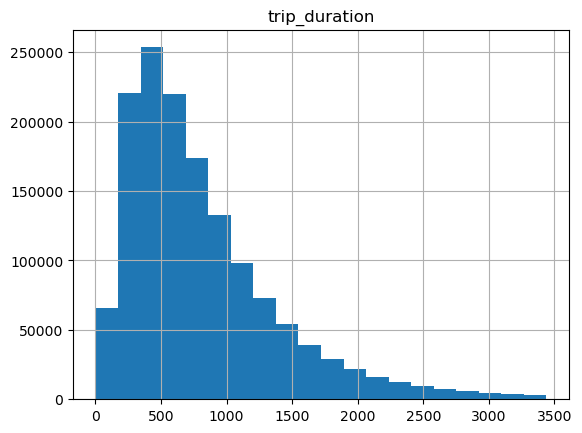

In [39]:
threshold = 0.99
trip_duration_threshold = df["trip_duration"].quantile(threshold)
filtered_threshold = df[df["trip_duration"] < trip_duration_threshold]
log_trip_duration = np.log(filtered_threshold["trip_duration"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(
    filtered_threshold["trip_duration"],
    bins=30,
    color="steelblue",
    edgecolor="white",
)
axes[0].set_title("Trip duration (raw)")
axes[0].set_xlabel("Trip duration (seconds)")
axes[0].set_ylabel("Number of trips")
axes[0].axvline(
    filtered_threshold["trip_duration"].median(),
    color="darkred",
    linestyle="--",
    linewidth=1.5,
    label=f"Median = {filtered_threshold['trip_duration'].median():.0f} s",
)
axes[0].legend()

axes[1].hist(
    log_trip_duration,
    bins=30,
    color="seagreen",
    edgecolor="white",
)
axes[1].set_title("Log-transformed trip duration")
axes[1].set_xlabel("log(trip duration)")
axes[1].set_ylabel("Number of trips")

fig.suptitle(
    f"Trip duration distributions (trips below {threshold:.0%} percentile)",
    y=1.02,
)
plt.tight_layout()
plt.savefig("figures/trip_duration_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

histogram shows that the majority of trips around around 500 seconds and that there is a long tail since the duration is right skewed. We filter the trip duration to the 99th percentile to avoid extreme outliers distorting the plots.

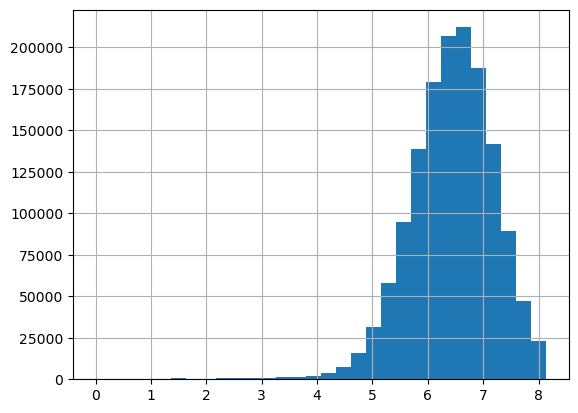

In [40]:
# Log histogram is shown in the side-by-side figure above.
log_trip_duration.describe()

Logging the trip duration and plotting the distribution makes it more bell shaped by reducing the skew. This will help when modelling by helping prevent heteroscedasticity and remove the effect of extreme outliers

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 9 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   vendor_id           1458644 non-null  int64  
 1   pickup_datetime     1458644 non-null  object 
 2   passenger_count     1458644 non-null  int64  
 3   pickup_longitude    1458644 non-null  float64
 4   pickup_latitude     1458644 non-null  float64
 5   dropoff_longitude   1458644 non-null  float64
 6   dropoff_latitude    1458644 non-null  float64
 7   store_and_fwd_flag  1458644 non-null  object 
 8   trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(2)
memory usage: 100.2+ MB


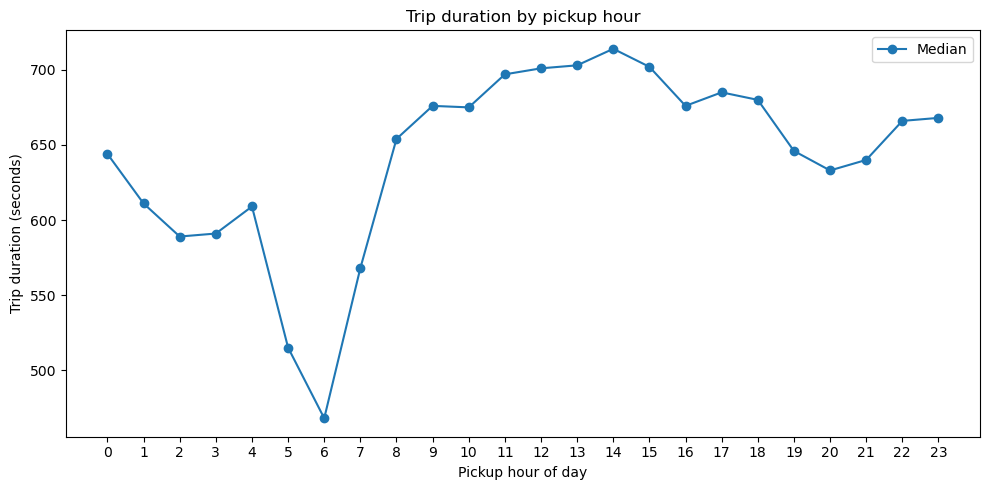

In [42]:
plot_df = filtered_threshold.copy()
plot_df["pickup_datetime"] = pd.to_datetime(plot_df["pickup_datetime"])
plot_df["pickup_hour"] = plot_df["pickup_datetime"].dt.hour

duration_by_hour = plot_df.groupby("pickup_hour")["trip_duration"].agg(["median", "mean"])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(duration_by_hour.index, duration_by_hour["median"], marker="o", label="Median")
ax.set_xlabel("Pickup hour of day")
ax.set_ylabel("Trip duration (seconds)")
ax.set_title("Trip duration by pickup hour")
ax.set_xticks(range(24))
ax.legend()
plt.tight_layout()
plt.show()

Given that the data is skewed we plot the median trip duration per hour. The results show that the longest trips are from 11am to 3pm and the shortest between 5am and 7am.

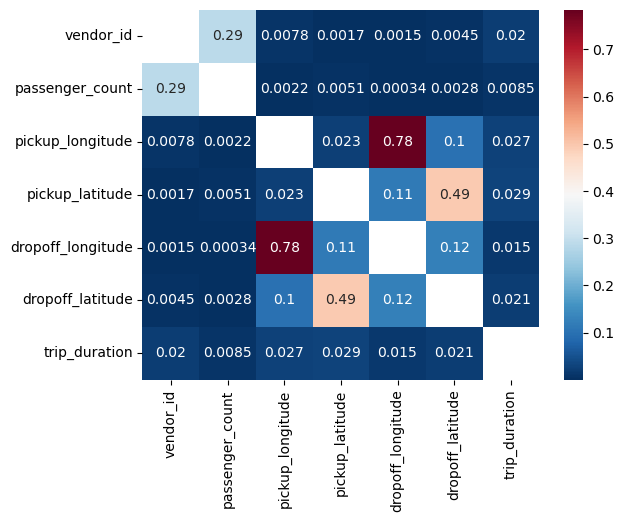

In [43]:
corr_matrix = df.select_dtypes(include=[np.number]).corr().abs()
mask = np.eye(len(corr_matrix), dtype=bool)
sns.heatmap(corr_matrix, annot=True, cmap="RdBu_r", mask=mask)
plt.show()


For the heatmap we omitted the middle diagonal to make the correlation between variables for apparent. The results show that pickup latitue/longititude have the highest correlation with trip duration

### How well does distance correlate with trip duration

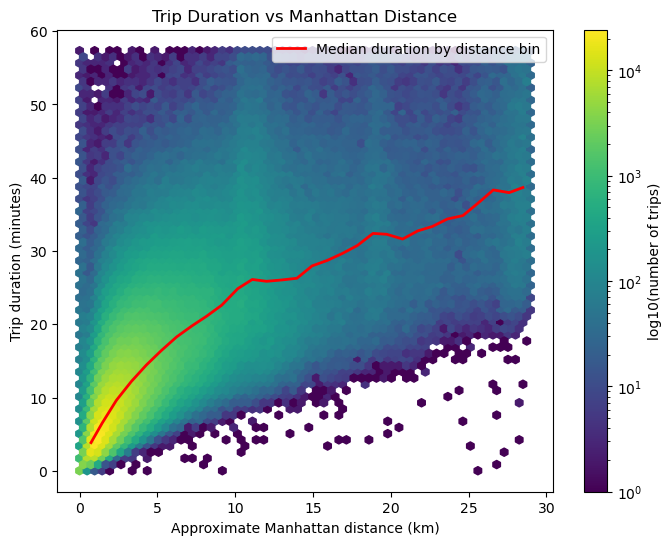

In [44]:
lat_km = 111
lon_km = 85  # longitude degree is about 85 km around NYC latitude

df["manhattan_km"] = (
    np.abs(df["dropoff_latitude"] - df["pickup_latitude"]) * lat_km
    + np.abs(df["dropoff_longitude"] - df["pickup_longitude"]) * lon_km
)
plot_df = df[
    (df["manhattan_km"] > 0) &
    (df["manhattan_km"] <= df["manhattan_km"].quantile(0.99)) &
    (df["trip_duration"] > 0) &
    (df["trip_duration"] <= df["trip_duration"].quantile(0.99))
].copy()

plot_df["trip_duration_min"] = plot_df["trip_duration"] / 60

plot_df["distance_bin"] = pd.cut(plot_df["manhattan_km"], bins=30)

trend = (
    plot_df.groupby("distance_bin", observed=True)
    .agg(
        median_distance=("manhattan_km", "median"),
        median_duration=("trip_duration_min", "median")
    )
    .dropna()
)

plt.figure(figsize=(8, 6))
hb = plt.hexbin(
    plot_df["manhattan_km"],
    plot_df["trip_duration_min"],
    gridsize=60,
    bins="log",
    mincnt=1
)

plt.plot(
    trend["median_distance"],
    trend["median_duration"],
    linewidth=2,
    label="Median duration by distance bin",
    color="red"
)

plt.xlabel("Approximate Manhattan distance (km)")
plt.ylabel("Trip duration (minutes)")
plt.title("Trip Duration vs Manhattan Distance")
plt.colorbar(hb, label="log10(number of trips)")
plt.legend()
plt.show()

Trip duration generally increases with Manhattan distance, but there is large vertical spread at each distance, suggesting that distance alone is not sufficient. This motivates adding temporal and spatial features such as pickup hour, day of week, and pickup/dropoff coordinates.

We quantify how many rows fail common validity checks (NYC bounding box, trip duration bounds, passenger count, date range, and implied speed). These counts will define our modeling cleaning pipeline.

In [45]:
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])

# NYC bounding box (common Kaggle / TLC filters)
LAT_MIN, LAT_MAX = 40.477399, 40.917577
LON_MIN, LON_MAX = -74.259090, -73.700272

coord_cols = [
    "pickup_latitude", "pickup_longitude",
    "dropoff_latitude", "dropoff_longitude",
]
in_nyc = np.ones(len(df), dtype=bool)
for col in coord_cols:
    if "latitude" in col:
        in_nyc &= df[col].between(LAT_MIN, LAT_MAX)
    else:
        in_nyc &= df[col].between(LON_MIN, LON_MAX)

valid_passengers = df["passenger_count"].between(1, 6)
valid_duration = df["trip_duration"].between(60, 24 * 3600)

valid_dates = df["pickup_datetime"].between(
    "2016-01-01", "2016-06-30 23:59:59"
)

if "manhattan_km" not in df.columns:
    lat_km, lon_km = 111, 85
    df["manhattan_km"] = (
        np.abs(df["dropoff_latitude"] - df["pickup_latitude"]) * lat_km
        + np.abs(df["dropoff_longitude"] - df["pickup_longitude"]) * lon_km
    )

positive_distance = df["manhattan_km"] > 0
speed_kmh = df["manhattan_km"] / (df["trip_duration"] / 3600)
valid_speed = speed_kmh.between(1, 120)

quality_checks = pd.DataFrame({
    "rule": [
        "coordinates in NYC bbox",
        "passenger_count in [1, 6]",
        "trip_duration in [60s, 24h]",
        "pickup in Jan–Jun 2016",
        "manhattan_km > 0",
        "implied speed in [1, 120] km/h",
    ],
    "rows_failing": [
        (~in_nyc).sum(),
        (~valid_passengers).sum(),
        (~valid_duration).sum(),
        (~valid_dates).sum(),
        (~positive_distance).sum(),
        (~valid_speed).sum(),
    ],
})
quality_checks["pct_of_data"] = (
    100 * quality_checks["rows_failing"] / len(df)
).round(3)
quality_checks

clean_mask = (
    in_nyc
    & valid_passengers
    & valid_duration
    & valid_dates
    & positive_distance
    & valid_speed
)
print(f"Rows passing all checks: {clean_mask.sum():,} ({100 * clean_mask.mean():.2f}%)")

Rows passing all checks: 1,439,362 (98.68%)


Only a small fraction of trips violate these rules; most failures come from bad GPS coordinates, impossible durations, or unrealistic implied speeds. For modeling we will train on the cleaned subset (`clean_mask`) so outliers do not dominate loss metrics.

Basic Summary stats on the cleaned subset used for modeling-oriented plots.

In [46]:
clean_df = df.loc[clean_mask].copy()
clean_df.describe().T

,count,mean,min,25%,50%,75%,max,std
vendor_id,1439362.0,1.534426,1.0,1.0,2.0,2.0,2.0,0.498814
pickup_datetime,1439362,2016-04-01 10:01:47.339097600,2016-01-01 00:00:17,2016-02-17 16:57:06.750000128,2016-04-01 16:50:43.500000,2016-05-15 03:23:59.750000128,2016-06-30 23:59:39,NaN
passenger_count,1439362.0,1.665055,1.0,1.0,1.0,2.0,6.0,1.314259
pickup_longitude,1439362.0,-73.973685,-74.250534,-73.991882,-73.981789,-73.967529,-73.708054,0.037568
pickup_latitude,1439362.0,40.751015,40.506294,40.737431,40.754139,40.768356,40.911556,0.027774
dropoff_longitude,1439362.0,-73.973675,-74.258675,-73.991333,-73.979797,-73.963203,-73.700302,0.034471
dropoff_latitude,1439362.0,40.751821,40.480194,40.735954,40.754551,40.769798,40.917469,0.031822
trip_duration,1439362.0,845.540278,60.0,401.0,665.0,1075.0,86392.0,908.461999
manhattan_km,1439362.0,4.481084,0.017017,1.606274,2.724979,5.046672,62.20734,5.181925


Categorical predictors

`vendor_id`, `passenger_count`, and `store_and_fwd_flag` are known at pickup time and are candidates for the model.

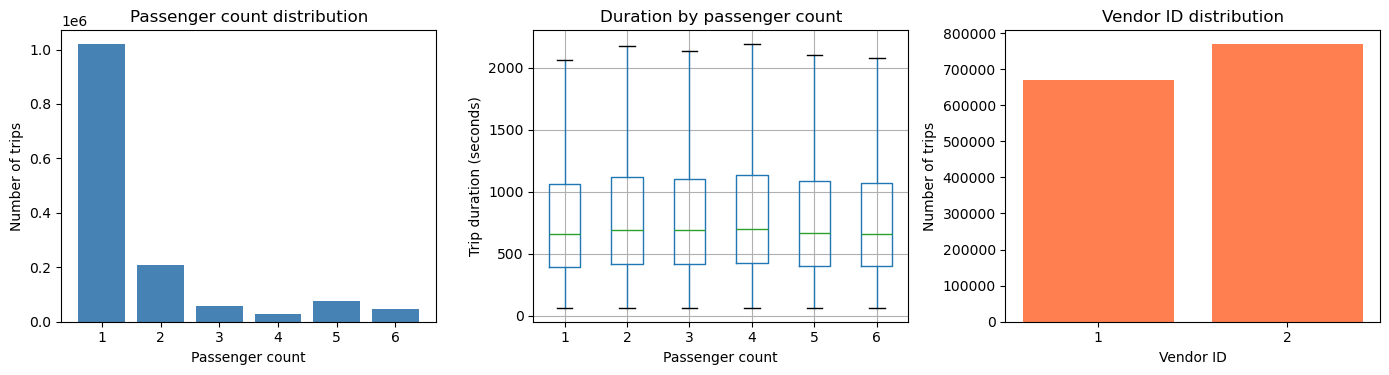

,n_trips,median,mean
store_and_fwd_flag,,,
N,1431520,664.0,844.157431
Y,7842,826.0,1097.972328


In [47]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

passenger_counts = clean_df["passenger_count"].value_counts().sort_index()
axes[0].bar(passenger_counts.index.astype(str), passenger_counts.values, color="steelblue")
axes[0].set_xlabel("Passenger count")
axes[0].set_ylabel("Number of trips")
axes[0].set_title("Passenger count distribution")

clean_df.boxplot(
    column="trip_duration",
    by="passenger_count",
    ax=axes[1],
    showfliers=False,
)
axes[1].set_xlabel("Passenger count")
axes[1].set_ylabel("Trip duration (seconds)")
axes[1].set_title("Duration by passenger count")
plt.suptitle("")

vendor_counts = clean_df["vendor_id"].value_counts().sort_index()
axes[2].bar(vendor_counts.index.astype(str), vendor_counts.values, color="coral")
axes[2].set_xlabel("Vendor ID")
axes[2].set_ylabel("Number of trips")
axes[2].set_title("Vendor ID distribution")

plt.tight_layout()
plt.show()

fwd_stats = (
    clean_df.groupby("store_and_fwd_flag")["trip_duration"]
    .agg(["count", "median", "mean"])
    .rename(columns={"count": "n_trips"})
)
fwd_stats

Almost all trips have one passenger; duration differs only slightly across passenger counts. `vendor_id` is imbalanced (two vendors). `store_and_fwd_flag == Y` is rare and has a slightly higher median duration—likely trips with delayed GPS upload rather than a strong causal signal. These features are weak alone but may still help tree-based models.

Trips span January–June 2016. We check volume and median duration by month and day of week to guide time-based validation splits.

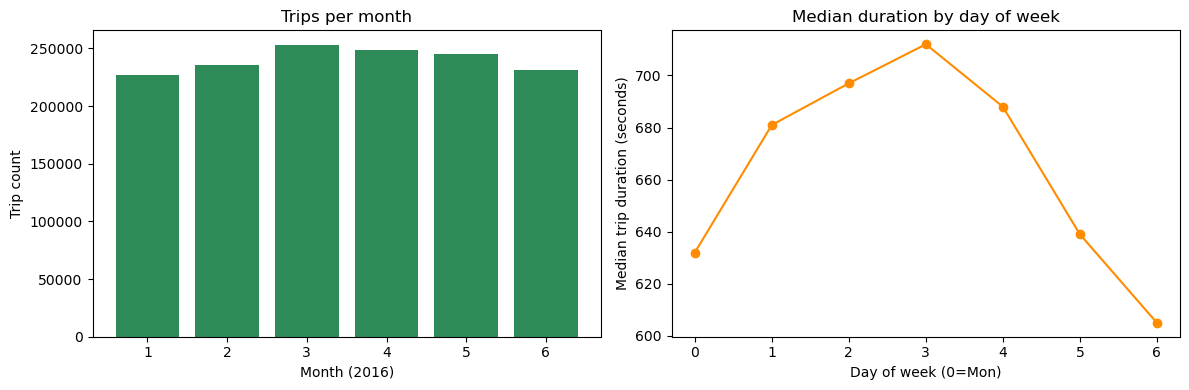

,n_trips,median_duration
pickup_month,,
1,226604,632.0
2,235199,638.0
3,252964,656.0
4,248323,678.0
5,245165,692.0
6,231107,698.0


In [48]:
clean_df["pickup_month"] = clean_df["pickup_datetime"].dt.month
clean_df["pickup_dow"] = clean_df["pickup_datetime"].dt.dayofweek
clean_df["pickup_hour"] = clean_df["pickup_datetime"].dt.hour

monthly = clean_df.groupby("pickup_month").agg(
    n_trips=("trip_duration", "size"),
    median_duration=("trip_duration", "median"),
)
dow = clean_df.groupby("pickup_dow").agg(
    n_trips=("trip_duration", "size"),
    median_duration=("trip_duration", "median"),
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(monthly.index, monthly["n_trips"], color="seagreen")
axes[0].set_xlabel("Month (2016)")
axes[0].set_ylabel("Trip count")
axes[0].set_title("Trips per month")
axes[0].set_xticks(range(1, 7))

axes[1].plot(dow.index, dow["median_duration"], marker="o", color="darkorange")
axes[1].set_xlabel("Day of week (0=Mon)")
axes[1].set_ylabel("Median trip duration (seconds)")
axes[1].set_title("Median duration by day of week")
axes[1].set_xticks(range(7))

plt.tight_layout()
plt.show()

monthly

Trip volume grows toward summer; median duration varies by month and day of week. A time-based holdout (e.g. last weeks of June) is more realistic than a random split because the test set in this competition is also from late June 2016.

Spatial overview

Pickup locations should concentrate in NYC. We plot a random sample of cleaned trips.

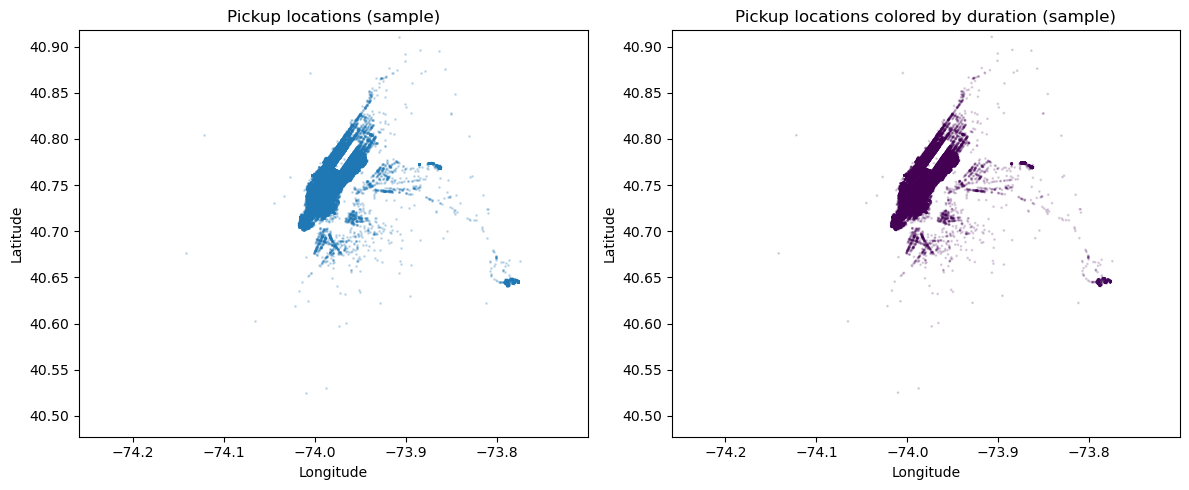

In [49]:
sample = clean_df.sample(n=50_000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(
    sample["pickup_longitude"],
    sample["pickup_latitude"],
    s=1,
    alpha=0.2,
    c="tab:blue",
)
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_title("Pickup locations (sample)")
axes[0].set_xlim(LON_MIN, LON_MAX)
axes[0].set_ylim(LAT_MIN, LAT_MAX)

axes[1].scatter(
    sample["pickup_longitude"],
    sample["pickup_latitude"],
    s=1,
    alpha=0.15,
    c=sample["trip_duration"],
    cmap="viridis",
)
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].set_title("Pickup locations colored by duration (sample)")
axes[1].set_xlim(LON_MIN, LON_MAX)
axes[1].set_ylim(LAT_MIN, LAT_MAX)

plt.tight_layout()
plt.show()

Pickups form the expected Manhattan-centric pattern; a few points remain near the bbox edge after cleaning. Duration is not uniform spatially—midtown and bridge/tunnel corridors tend toward longer trips—supporting location-based features (coordinates or cluster IDs) beyond distance alone.

Train vs test split (competition files)

Confirming that  held-out test set has the same schema and similar pickup-time range.

In [50]:
test = pd.read_csv("data/test.csv")
test["pickup_datetime"] = pd.to_datetime(test["pickup_datetime"])

comparison = pd.DataFrame({
    "rows": [len(df), len(test)],
    "pickup_min": [df["pickup_datetime"].min(), test["pickup_datetime"].min()],
    "pickup_max": [df["pickup_datetime"].max(), test["pickup_datetime"].max()],
    "median_passengers": [df["passenger_count"].median(), test["passenger_count"].median()],
}, index=["train", "test"])
comparison

,rows,pickup_min,pickup_max,median_passengers
train,1458644,2016-01-01 00:00:17,2016-06-30 23:59:39,1.0
test,625134,2016-01-01 00:00:22,2016-06-30 23:59:58,1.0


The test set has no `trip_duration` labels and pickups concentrated at the end of June 2016. Internal evaluation should mimic that with a **time-based validation** slice, not random cross-validation only.

## Implications for modeling

| Finding | Modeling choice |
|--------|------------------|
| Right-skewed `trip_duration` | Train on `log1p(trip_duration)`; report RMSE in log space and/or back-transformed seconds |
| Distance explains trend, not spread | Use Manhattan/haversine distance plus richer location features (raw coords, bearing, KMeans zone IDs) |
| Strong hour-of-day / DOW effects | Cyclical or one-hot time features from `pickup_datetime` |
| ~1–2% rows fail quality checks | Apply `clean_mask` before training; document dropped counts |
| Weak `passenger_count` / categoricals | Include for completeness; expect small gain |
| Test pickups late June 2016 | Validate on last weeks of training time |

**Predictive task (final):** Given pickup time, pickup/dropoff coordinates, passenger count, and vendor/flag at trip start, predict `trip_duration` in seconds.

**Planned baselines:** global mean/median → linear model on distance + hour → gradient boosting (e.g. XGBoost/LightGBM) with engineered features above.